# Evaluate Vision Models on Size Illusions

In [1]:
!pip3 install -q torch torchvision transformers pillow datasets matplotlib pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image

def resolve_data_root():
    preferred = Path('mnt/cs/cs153/data/anika-livia')
    local_fallback = (Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()) / 'data'
    env_override = os.environ.get('CS153_DATA_ROOT')
    if env_override:
        p = Path(env_override).resolve()
        p.mkdir(parents=True, exist_ok=True)
        return p
    try:
        preferred.mkdir(parents=True, exist_ok=True)
        test = preferred / '.write_test'
        test.write_text('ok', encoding='utf-8')
        test.unlink()
        return preferred
    except Exception:
        local_fallback.mkdir(parents=True, exist_ok=True)
        return local_fallback.resolve()

PROJECT_ROOT = Path(os.environ.get('CS153_PROJECT_ROOT', 'mnt/cs/cs153/projects/size_illusion_project')).resolve()
try:
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
except Exception:
    PROJECT_ROOT = ((Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()) / 'project').resolve()
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

DATA_ROOT = resolve_data_root()

CODE_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from data.generate_illusions import generate_dataset
from datasets.synthetic_loader import SyntheticIllusionDataset, ID_TO_LABEL, LABEL_TO_ID
from datasets.illusionvqa_loader import load_illusionvqa_size, to_eval_examples
from models.cnn_model import build_resnet50, build_efficientnet_b0, extract_features, train_probe, predict_probe, predict_probe_task_masked
from models.vit_model import build_vit_b16
from models.clip_eval import build_clip, clip_predict, IVQA_LABELS

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_ROOT =', DATA_ROOT)
device


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.0.1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT = /Users/anikapandey/computerVisionFinal/notebooks/mnt/cs/cs153/projects/size_illusion_project
DATA_ROOT = mnt/cs/cs153/data/anika-livia


'cpu'

In [3]:
data_root = DATA_ROOT / 'synthetic_illusions'
data_root.mkdir(parents=True, exist_ok=True)
# Regenerates train+test PNGs (PIL); ~1–4 min for 2400 images on a typical laptop.
# Larger split helps the 5-way probe; doubles regen + feature extraction time vs 900/300.
train_n = 1800
test_n = 600
generate_dataset(data_root, 'train', train_n, with_context=False, seed=10)
generate_dataset(data_root, 'test', test_n, with_context=True, seed=11)
print('synthetic data ready at', data_root, 'train_n=', train_n, 'test_n=', test_n)


synthetic data ready at mnt/cs/cs153/data/anika-livia/synthetic_illusions train_n= 1800 test_n= 600


In [4]:
resnet, res_tfm, res_dim = build_resnet50(device)
effnet, eff_tfm, eff_dim = build_efficientnet_b0(device)
vit, vit_tfm, vit_dim = build_vit_b16(device)
clip_model, clip_processor = build_clip(device)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [5]:
# CPU: most time is 6× feature extraction (3 backbones × train+test); often ~15–45 min
# total on a laptop CPU after weights are cached—ViT is the slowest. Probe fit is seconds.
probe_epochs = 80

train_res = SyntheticIllusionDataset(data_root, 'train', transform=res_tfm)
test_res = SyntheticIllusionDataset(data_root, 'test', transform=res_tfm)
x_tr_r, y_tr, train_rows = extract_features(resnet, train_res, device)
x_te_r, y_te, rows_te = extract_features(resnet, test_res, device)
head_r = train_probe(x_tr_r, y_tr, res_dim, epochs=probe_epochs, device=device)
pred_r, _ = predict_probe_task_masked(head_r, x_te_r, rows_te, device=device)
pred_train_r, _ = predict_probe_task_masked(head_r, x_tr_r, train_rows, device=device)

train_eff = SyntheticIllusionDataset(data_root, 'train', transform=eff_tfm)
test_eff = SyntheticIllusionDataset(data_root, 'test', transform=eff_tfm)
x_tr_e, y_tr_e, _ = extract_features(effnet, train_eff, device)
x_te_e, y_te_e, _ = extract_features(effnet, test_eff, device)
head_e = train_probe(x_tr_e, y_tr_e, eff_dim, epochs=probe_epochs, device=device)
pred_e, _ = predict_probe_task_masked(head_e, x_te_e, rows_te, device=device)
pred_train_e, _ = predict_probe_task_masked(head_e, x_tr_e, train_rows, device=device)

train_vit = SyntheticIllusionDataset(data_root, 'train', transform=vit_tfm)
test_vit = SyntheticIllusionDataset(data_root, 'test', transform=vit_tfm)
x_tr_v, y_tr_v, _ = extract_features(vit, train_vit, device)
x_te_v, y_te_v, _ = extract_features(vit, test_vit, device)
head_v = train_probe(x_tr_v, y_tr_v, vit_dim, epochs=probe_epochs, device=device)
pred_v, _ = predict_probe_task_masked(head_v, x_te_v, rows_te, device=device)
pred_train_v, _ = predict_probe_task_masked(head_v, x_tr_v, train_rows, device=device)


In [6]:
def acc_and_bias(pred_ids, gt_ids):
    n = len(gt_ids)
    acc = (pred_ids == gt_ids).float().mean().item()
    illusion_bias = (pred_ids != gt_ids).float().mean().item()
    return acc, illusion_bias

def label_from_text(x):
    t = str(x).lower()
    if "left" in t:
        return "left"
    if "right" in t:
        return "right"
    if "equal" in t or "same" in t:
        return "equal"
    return None

In [7]:
gt_train = y_tr
no_ill_acc_r, _ = acc_and_bias(pred_train_r, gt_train)
no_ill_acc_e, _ = acc_and_bias(pred_train_e, y_tr_e)
no_ill_acc_v, _ = acc_and_bias(pred_train_v, y_tr_v)

test_gt = y_te
ill_acc_r, ill_bias_r = acc_and_bias(pred_r, test_gt)
ill_acc_e, ill_bias_e = acc_and_bias(pred_e, y_te_e)
ill_acc_v, ill_bias_v = acc_and_bias(pred_v, y_te_v)

clip_train = SyntheticIllusionDataset(data_root, 'train', transform=None)
clip_test = SyntheticIllusionDataset(data_root, 'test', transform=None)
clip_train_max = min(180, len(clip_train))
clip_test_max = min(180, len(clip_test))
clip_pred_train, clip_gt_train = [], []
for i in range(clip_train_max):
    im, y, row = clip_train[i]
    p, _, _ = clip_predict(clip_model, clip_processor, im, row=row, device=device)
    clip_pred_train.append(LABEL_TO_ID[p])
    clip_gt_train.append(y)
clip_pred_test, clip_gt_test = [], []
for i in range(clip_test_max):
    im, y, row = clip_test[i]
    p, _, _ = clip_predict(clip_model, clip_processor, im, row=row, device=device)
    clip_pred_test.append(LABEL_TO_ID[p])
    clip_gt_test.append(y)
clip_pred_train = torch.tensor(clip_pred_train)
clip_gt_train = torch.tensor(clip_gt_train)
clip_pred_test = torch.tensor(clip_pred_test)
clip_gt_test = torch.tensor(clip_gt_test)
no_ill_acc_c, _ = acc_and_bias(clip_pred_train, clip_gt_train)
ill_acc_c, ill_bias_c = acc_and_bias(clip_pred_test, clip_gt_test)

synthetic_results = pd.DataFrame(
    [
        ['ResNet50', no_ill_acc_r, ill_acc_r, ill_bias_r],
        ['EfficientNet-B0', no_ill_acc_e, ill_acc_e, ill_bias_e],
        ['ViT-B/16', no_ill_acc_v, ill_acc_v, ill_bias_v],
        ['CLIP', no_ill_acc_c, ill_acc_c, ill_bias_c],
    ],
    columns=['Model', 'No-illusion acc', 'Illusion acc', 'Illusion bias'],
)
print('CLIP synthetic evaluated on', clip_train_max, 'train and', clip_test_max, 'test samples for CPU speed')
synthetic_results


CLIP synthetic evaluated on 180 train and 180 test samples for CPU speed


,Model,No-illusion acc,Illusion acc,Illusion bias
0,ResNet50,0.921667,0.353333,0.646667
1,EfficientNet-B0,0.684444,0.401667,0.598333
2,ViT-B/16,0.610000,0.438333,0.561667
3,CLIP,0.333333,0.383333,0.616667


In [8]:
ivqa = load_illusionvqa_size(split='test')
ivqa_examples = to_eval_examples(ivqa)
ivqa_examples = [x for x in ivqa_examples if label_from_text(x.get('answer')) is not None]
ivqa_max = min(250, len(ivqa_examples))
ivqa_examples = ivqa_examples[:ivqa_max]
print('IllusionVQA size examples used:', len(ivqa_examples))


DatasetNotFoundError: Dataset 'IllusionVQA/IllusionVQA' doesn't exist on the Hub or cannot be accessed.

In [ ]:
def eval_ivqa_model(name):
    preds = []
    gts = []
    for ex in ivqa_examples:
        image = ex["image"].convert("RGB") if hasattr(ex["image"], "convert") else Image.fromarray(ex["image"])
        gt = label_from_text(ex["answer"])
        if gt is None:
            continue
        gts.append({"left": 0, "right": 1, "equal": 2}[gt])
        if name == "CLIP":
            p, _, _ = clip_predict(clip_model, clip_processor, image, labels=IVQA_LABELS, device=device)
            preds.append({"left": 0, "right": 1, "equal": 2}[p])
        elif name == "ResNet50":
            x = res_tfm(image).unsqueeze(0).to(device)
            with torch.no_grad():
                f = resnet(x).cpu()
            p, _ = predict_probe(head_r.to("cpu"), f)
            preds.append(int(p[0]))
        elif name == "EfficientNet-B0":
            x = eff_tfm(image).unsqueeze(0).to(device)
            with torch.no_grad():
                f = effnet(x).cpu()
            p, _ = predict_probe(head_e.to("cpu"), f)
            preds.append(int(p[0]))
        else:
            x = vit_tfm(image).unsqueeze(0).to(device)
            with torch.no_grad():
                f = vit(x).cpu()
            p, _ = predict_probe(head_v.to("cpu"), f)
            preds.append(int(p[0]))
    preds = torch.tensor(preds)
    gts = torch.tensor(gts)
    acc, bias = acc_and_bias(preds, gts)
    return acc, bias

ivqa_rows = []
for name in ["ResNet50", "EfficientNet-B0", "ViT-B/16", "CLIP"]:
    acc, bias = eval_ivqa_model(name)
    ivqa_rows.append([name, None, acc, bias])
ivqa_results = pd.DataFrame(ivqa_rows, columns=["Model", "No-illusion acc", "Illusion acc", "Illusion bias"])
ivqa_results

NameError: name 'ivqa_examples' is not defined

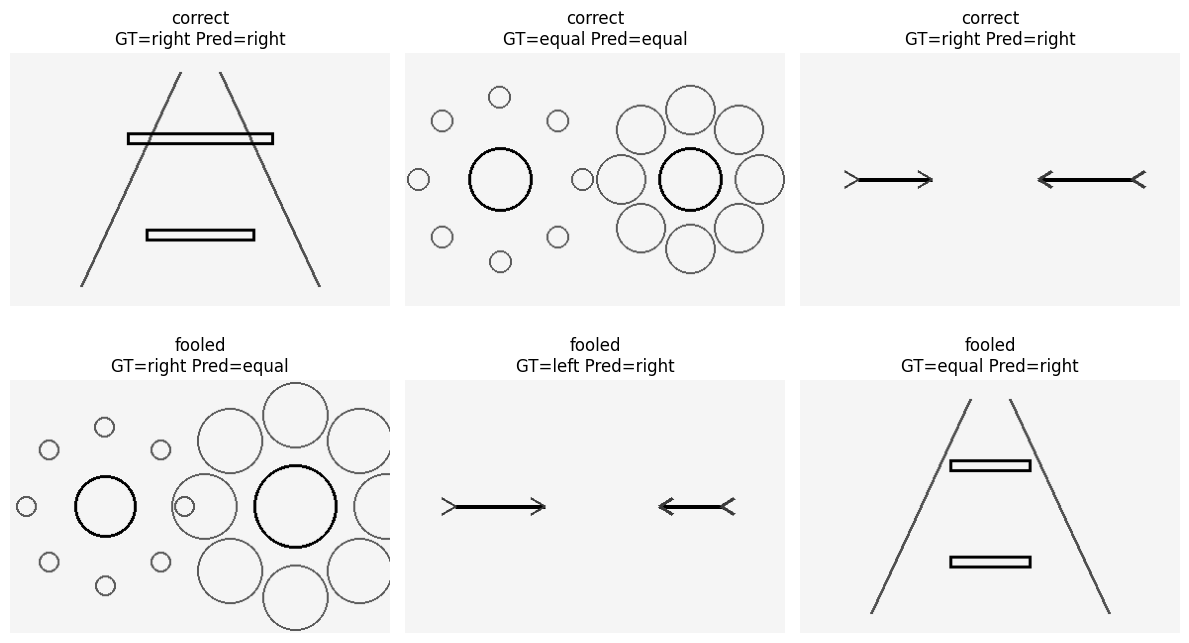

In [ ]:
rows = SyntheticIllusionDataset(data_root, "test", transform=None).rows
pred_lbl_res = [ID_TO_LABEL[int(x)] for x in pred_r]
gt_lbl = [r["ground_truth"] for r in rows]
correct_idx = [i for i, (p, g) in enumerate(zip(pred_lbl_res, gt_lbl)) if p == g][:3]
fooled_idx = [i for i, (p, g) in enumerate(zip(pred_lbl_res, gt_lbl)) if p != g][:3]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for col, idx in enumerate(correct_idx):
    row = rows[idx]
    im = Image.open(data_root / row["image_path"])
    axes[0, col].imshow(im)
    axes[0, col].set_title(f"correct\nGT={row['ground_truth']} Pred={pred_lbl_res[idx]}")
    axes[0, col].axis("off")
for col, idx in enumerate(fooled_idx):
    row = rows[idx]
    im = Image.open(data_root / row["image_path"])
    axes[1, col].imshow(im)
    axes[1, col].set_title(f"fooled\nGT={row['ground_truth']} Pred={pred_lbl_res[idx]}")
    axes[1, col].axis("off")
plt.tight_layout()
plt.show()